# Ice-Ice Disease Classification: Classical DIP + SVM
**Ablation Study**: Baseline vs Median Filter vs CLAHE vs Median + CLAHE

| Component | Choice |
|---|---|
| Features | HSV color histogram (96-dim) |
| Classifier | SVM with RBF kernel (default hyperparameters) |
| Dataset | *Kappaphycus alvarezii* — healthy vs early signs of ice-ice disease |
| Evaluation | Accuracy, Precision, Recall, F1-score |

The pipeline keeps the classifier fixed across all 4 conditions so that any performance difference is attributable only to the preprocessing step under test.

## 1. Imports and Setup

In [21]:
# Standard libraries
import os
import glob
import time

# Image processing and numerical computing
import cv2
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Matplotlib styling
sns.set_style('white')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Configuration

All experiment settings are centralized here. Change once, applies everywhere.

In [22]:
# Dataset root (must contain train/ and test/, each with early_signs/ and healthy/ subfolders)
DATASET_DIR = r'C:\Users\alkad\OneDrive\Desktop\UTS\dataset'
TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
TEST_DIR  = os.path.join(DATASET_DIR, 'test')

# Class label mapping: 0 = healthy (negative), 1 = early signs (positive class)
CLASS_NAMES = ['healthy', 'early_signs']
LABEL_MAP = {'healthy': 0, 'early_signs': 1}

# Standard input size after resize (color histograms are scale-invariant, but smaller = faster)
IMG_SIZE = 256

# HSV histogram bins per channel; final feature vector = 3 channels x 32 bins = 96-dim
HIST_BINS = 32

# CLAHE parameters (applied on L channel of CIELAB color space)
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID = (8, 8)

# Median filter kernel size (must be odd)
MEDIAN_KERNEL = 5

# Ablation configurations: name -> (apply_median, apply_clahe)
ABLATION_CONFIGS = {
    'baseline': (False, False),
    'median':   (True,  False),
    'clahe':    (False, True),
    'both':     (True,  True),
}

print('Configuration set')
print(f'Dataset: {DATASET_DIR}')
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Feature dim: {3 * HIST_BINS}')

Configuration set
Dataset: C:\Users\alkad\OneDrive\Desktop\UTS\dataset
Image size: 256x256
Feature dim: 96


## 3. Load Dataset

Image paths are collected from both `train/` and `test/` folders, then **combined and stratified 80/20 re-split** with a fixed seed. This is done because initial experiments revealed domain shift between the original train/test partitions; pooling and re-splitting ensures both partitions come from the same distribution. The actual images are not loaded into memory yet — only their paths.

In [ ]:
def load_image_paths(folder):
    """Walk through a folder with two class subfolders and return paths + labels."""
    image_paths = []
    labels = []
    for class_name in CLASS_NAMES:
        class_folder = os.path.join(folder, class_name)
        for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
            for path in glob.glob(os.path.join(class_folder, ext)):
                image_paths.append(path)
                labels.append(LABEL_MAP[class_name])
    return image_paths, np.array(labels)


# Load paths from both train and test folders
train_paths_raw, train_labels_raw = load_image_paths(TRAIN_DIR)
test_paths_raw,  test_labels_raw  = load_image_paths(TEST_DIR)

print(f'Original train folder: {len(train_paths_raw)} images')
print(f'Original test folder:  {len(test_paths_raw)} images')

# Pool all images then apply a stratified 80/20 random split
# (fixes the domain shift observed in the original train/test partitions)
from sklearn.model_selection import train_test_split

all_paths  = train_paths_raw + test_paths_raw
all_labels = np.concatenate([train_labels_raw, test_labels_raw])

train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=RANDOM_STATE
)
train_paths = list(train_paths)
test_paths  = list(test_paths)

print()
print('After combined stratified 80/20 split:')
print(f'Train: {len(train_paths)} images')
print(f'  - healthy:     {(train_labels == 0).sum()}')
print(f'  - early_signs: {(train_labels == 1).sum()}')
print(f'Test:  {len(test_paths)} images')
print(f'  - healthy:     {(test_labels == 0).sum()}')
print(f'  - early_signs: {(test_labels == 1).sum()}')

## 4. Visualization #1 — Sample Images

Display 2 random samples from each class so we can see what the dataset looks like.

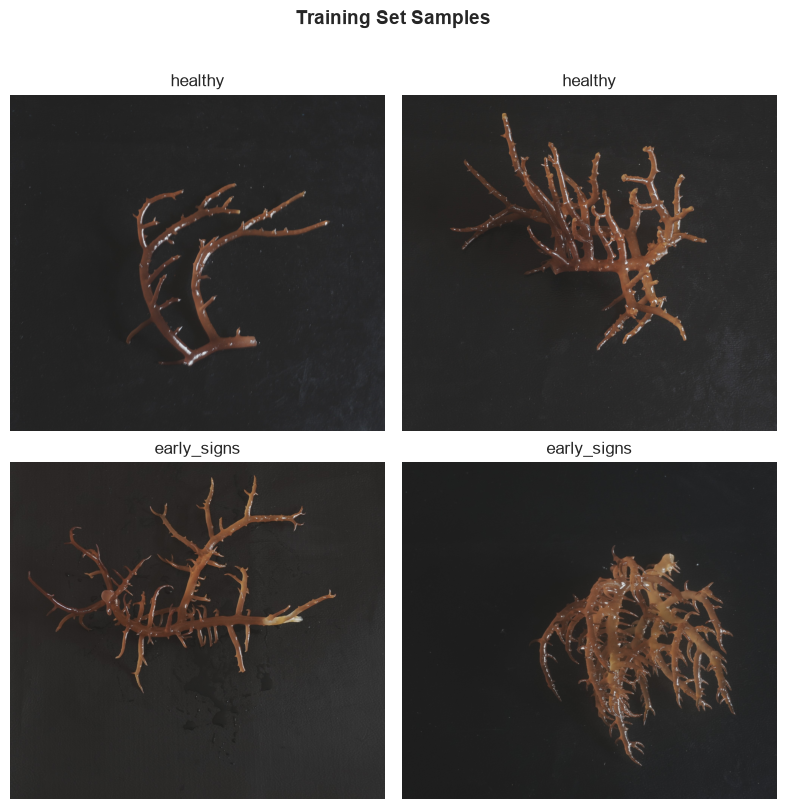

In [24]:
def show_samples_grid(paths, labels, n_per_class=2, title='Sample Images'):
    """Display n random samples per class in a grid."""
    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 4, 8))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    for row, class_idx in enumerate([0, 1]):  # 0 = healthy, 1 = early_signs
        # Get indices of images for this class
        class_indices = np.where(labels == class_idx)[0]
        # Pick n random samples
        chosen = np.random.choice(class_indices, n_per_class, replace=False)

        for col, idx in enumerate(chosen):
            img = cv2.imread(paths[idx])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV uses BGR, matplotlib expects RGB

            ax = axes[row, col] if n_per_class > 1 else axes[row]
            ax.imshow(img_rgb)
            ax.set_title(CLASS_NAMES[class_idx], fontsize=12)
            ax.axis('off')

    plt.tight_layout()
    plt.show()


# Show samples from training set
show_samples_grid(train_paths, train_labels, n_per_class=2, title='Training Set Samples')

## 5. Preprocessing Functions

Two operations: **median filter** (denoise) and **CLAHE** (contrast enhancement).
When both are enabled, median runs first so CLAHE doesn't amplify noise.

In [25]:
def apply_median(img, ksize=MEDIAN_KERNEL):
    """Apply median filter for noise reduction.

    The median filter is non-linear: each pixel is replaced by the median of its
    surrounding neighborhood. Effective against salt-and-pepper noise while
    preserving edges (unlike Gaussian smoothing).
    """
    return cv2.medianBlur(img, ksize)


def apply_clahe(img, clip=CLAHE_CLIP_LIMIT, tile=CLAHE_TILE_GRID):
    """Apply CLAHE on the L channel of CIELAB color space.

    Working in LAB and applying CLAHE only to the L (lightness) channel preserves
    color fidelity. The a and b chrominance channels are left untouched.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    l_enhanced = clahe.apply(l)
    lab_enhanced = cv2.merge([l_enhanced, a, b])
    return cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)


def preprocess(img, use_median=False, use_clahe=False):
    """Apply the full preprocessing pipeline based on ablation flags.

    Order matters: median FIRST, then CLAHE. This denoises before contrast
    enhancement, so CLAHE doesn't amplify noise.
    """
    if use_median:
        img = apply_median(img)
    if use_clahe:
        img = apply_clahe(img)
    return img


print('Preprocessing functions defined')

Preprocessing functions defined


## 6. Visualization #2 — Preprocessing Comparison

Apply all 4 ablation configurations to the same image and display side-by-side.
This is **Figure 2 for your report**.

Healthy sample:
Saved figure to preprocessing_healthy.png


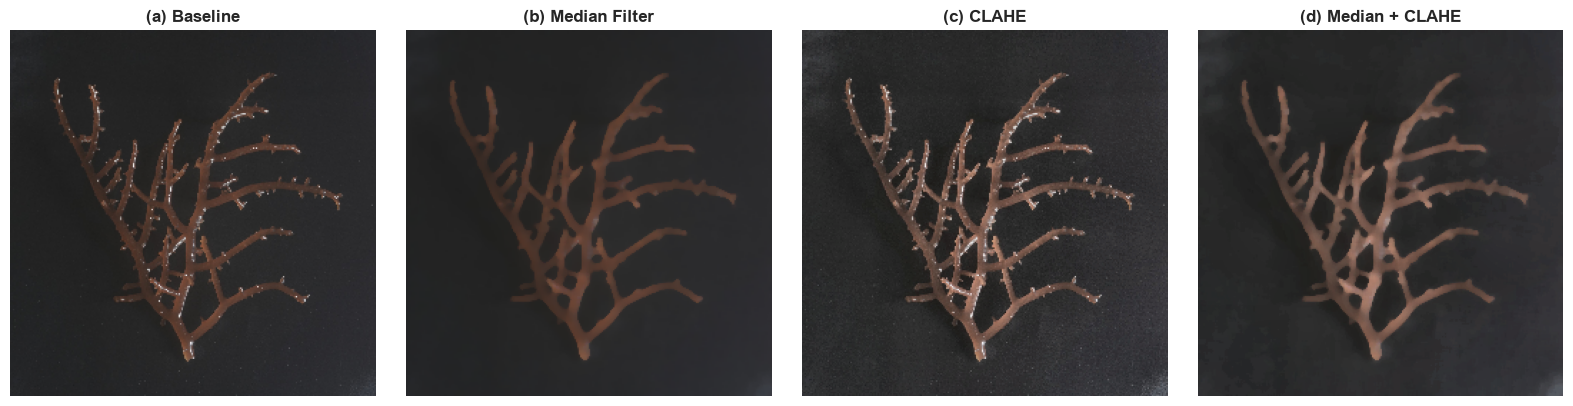

Early-signs sample:
Saved figure to preprocessing_disease.png


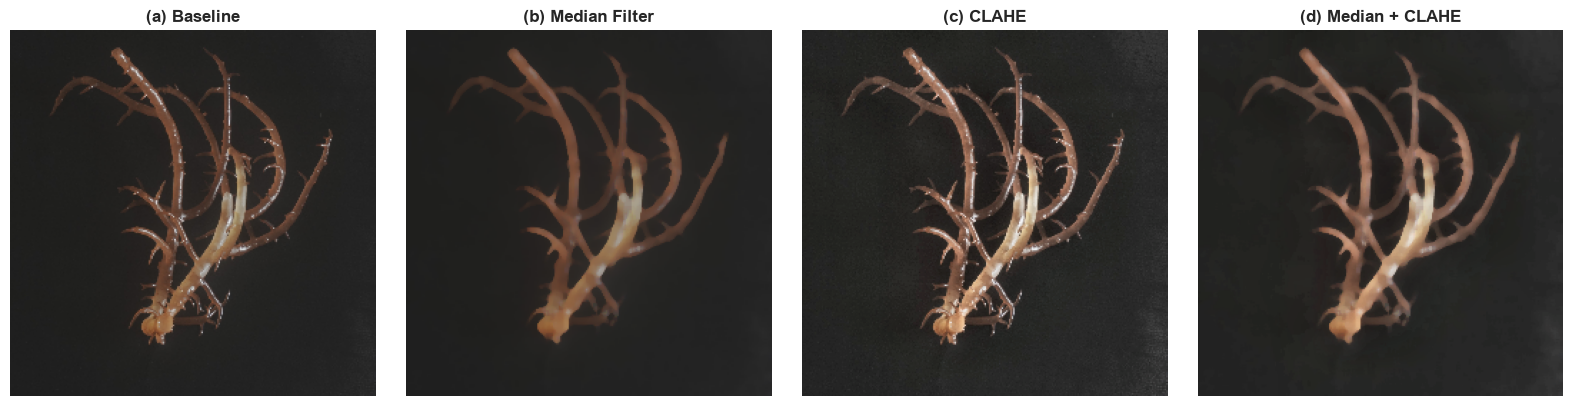

In [26]:
def show_preprocessing_comparison(image_path, save_path=None):
    """Display the same image under all 4 preprocessing configurations."""
    img = cv2.imread(image_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # standardize size

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    titles = ['(a) Baseline', '(b) Median Filter', '(c) CLAHE', '(d) Median + CLAHE']

    for ax, (name, (use_m, use_c)), title in zip(axes, ABLATION_CONFIGS.items(), titles):
        processed = preprocess(img.copy(), use_median=use_m, use_clahe=use_c)
        ax.imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved figure to {save_path}')
    plt.show()


# Pick one healthy and one diseased image for comparison
healthy_idx = np.where(train_labels == 0)[0][0]
disease_idx = np.where(train_labels == 1)[0][0]

print('Healthy sample:')
show_preprocessing_comparison(train_paths[healthy_idx], save_path='preprocessing_healthy.png')

print('Early-signs sample:')
show_preprocessing_comparison(train_paths[disease_idx], save_path='preprocessing_disease.png')

## 7. Feature Extraction — HSV Color Histogram

Convert image to HSV, compute per-channel histogram (32 bins each), concatenate, L1-normalize.
Resulting feature vector is 96-dimensional.

**Why HSV**: Separates color (hue/saturation) from brightness (value). Ice-ice disease shows up primarily as a *color* change (whitening), so HSV captures the discriminative signal better than RGB.

In [27]:
def extract_hsv_histogram(img, bins=HIST_BINS):
    """Compute a normalized HSV color histogram.

    Returns a 1-D feature vector of length (3 * bins).
    """
    # Convert from BGR (OpenCV default) to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Compute per-channel histogram
    histograms = []
    for ch in range(3):  # H, S, V channels
        hist = cv2.calcHist([hsv], [ch], None, [bins], [0, 256])
        histograms.append(hist.flatten())

    # Concatenate H, S, V histograms into one vector
    feature = np.concatenate(histograms)

    # L1 normalize so total area = 1 (makes features comparable across images)
    feature = feature / (feature.sum() + 1e-7)

    return feature


# Quick test on one image
sample_img = cv2.imread(train_paths[0])
sample_img = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))
sample_feat = extract_hsv_histogram(sample_img)
print(f'Feature vector shape: {sample_feat.shape}')
print(f'Sum after normalization: {sample_feat.sum():.4f} (should be ~1.0)')

Feature vector shape: (96,)
Sum after normalization: 1.0000 (should be ~1.0)


## 8. Visualization #3 — HSV Histograms by Class

Compare the HSV histogram signature of healthy vs diseased seaweed.
If our feature choice is good, the two classes should look visibly different.

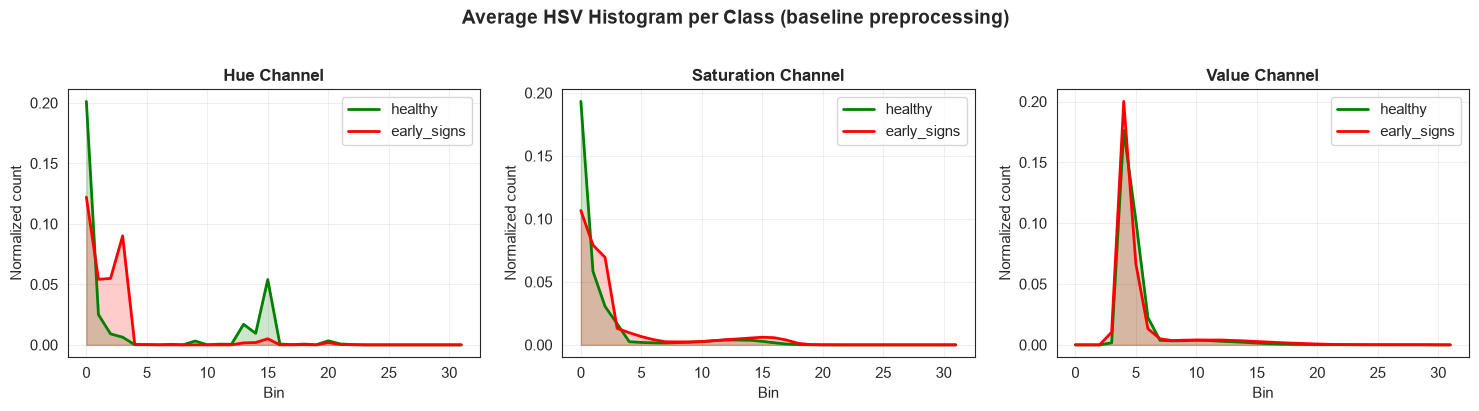

In [28]:
def plot_class_histograms(paths, labels, n_samples=10):
    """Plot average HSV histogram per class."""
    avg_hist = {0: np.zeros(3 * HIST_BINS), 1: np.zeros(3 * HIST_BINS)}
    counts = {0: 0, 1: 0}

    # Average over n_samples per class
    for class_idx in [0, 1]:
        indices = np.where(labels == class_idx)[0][:n_samples]
        for idx in indices:
            img = cv2.imread(paths[idx])
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            feat = extract_hsv_histogram(img)
            avg_hist[class_idx] += feat
            counts[class_idx] += 1
        avg_hist[class_idx] /= counts[class_idx]

    # Plot — three panels (H, S, V), with both classes overlaid
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    channels = ['Hue', 'Saturation', 'Value']
    colors = {'healthy': 'green', 'early_signs': 'red'}

    for i, (ax, ch_name) in enumerate(zip(axes, channels)):
        start, end = i * HIST_BINS, (i + 1) * HIST_BINS
        x = np.arange(HIST_BINS)
        ax.plot(x, avg_hist[0][start:end], label='healthy',     color=colors['healthy'], linewidth=2)
        ax.plot(x, avg_hist[1][start:end], label='early_signs', color=colors['early_signs'], linewidth=2)
        ax.fill_between(x, avg_hist[0][start:end], alpha=0.2, color=colors['healthy'])
        ax.fill_between(x, avg_hist[1][start:end], alpha=0.2, color=colors['early_signs'])
        ax.set_title(f'{ch_name} Channel', fontsize=12, fontweight='bold')
        ax.set_xlabel('Bin')
        ax.set_ylabel('Normalized count')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('Average HSV Histogram per Class (baseline preprocessing)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('histogram_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_class_histograms(train_paths, train_labels, n_samples=20)

## 9. Build Feature Matrices

For efficiency, we **load each image once** and extract features under all 4 preprocessing configurations in a single pass.

Output: a dictionary `{config_name: feature_matrix}` for train and test sets.

In [29]:
def build_all_features(paths, labels, verbose=True):
    """Extract features for all 4 ablation configs in a single pass over the dataset."""
    # Initialize storage
    features = {name: [] for name in ABLATION_CONFIGS}

    start = time.time()
    for i, path in enumerate(paths):
        # Load image once
        img = cv2.imread(path)
        if img is None:
            print(f'Warning: could not read {path}')
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Apply each preprocessing config and extract features
        for name, (use_m, use_c) in ABLATION_CONFIGS.items():
            processed = preprocess(img.copy(), use_median=use_m, use_clahe=use_c)
            feat = extract_hsv_histogram(processed)
            features[name].append(feat)

        # Progress
        if verbose and (i + 1) % 50 == 0:
            print(f'  Processed {i + 1}/{len(paths)} images')

    # Convert lists to numpy arrays
    features = {name: np.array(feats) for name, feats in features.items()}
    elapsed = time.time() - start
    if verbose:
        print(f'Done in {elapsed:.1f}s')

    return features, labels


print('Extracting features for TRAIN set...')
X_train_all, y_train = build_all_features(train_paths, train_labels)

print()
print('Extracting features for TEST set...')
X_test_all, y_test = build_all_features(test_paths, test_labels)

print()
print('Feature matrix shapes (per config):')
for name in ABLATION_CONFIGS:
    print(f'  {name:10s} train: {X_train_all[name].shape}  test: {X_test_all[name].shape}')

Extracting features for TRAIN set...
  Processed 50/3200 images
  Processed 100/3200 images
  Processed 150/3200 images
  Processed 200/3200 images
  Processed 250/3200 images
  Processed 300/3200 images
  Processed 350/3200 images
  Processed 400/3200 images
  Processed 450/3200 images
  Processed 500/3200 images
  Processed 550/3200 images
  Processed 600/3200 images
  Processed 650/3200 images
  Processed 700/3200 images
  Processed 750/3200 images
  Processed 800/3200 images
  Processed 850/3200 images
  Processed 900/3200 images
  Processed 950/3200 images
  Processed 1000/3200 images
  Processed 1050/3200 images
  Processed 1100/3200 images
  Processed 1150/3200 images
  Processed 1200/3200 images
  Processed 1250/3200 images
  Processed 1300/3200 images
  Processed 1350/3200 images
  Processed 1400/3200 images
  Processed 1450/3200 images
  Processed 1500/3200 images
  Processed 1550/3200 images
  Processed 1600/3200 images
  Processed 1650/3200 images
  Processed 1700/3200 imag

## 10. Train Multiple Classifiers Across All Configurations

We train **4 supervised classifiers** on each of the 4 ablation configurations (16 model-configuration combinations total):

| Classifier | Type | Notes |
|---|---|---|
| **SVM (RBF)** | Margin-based | Strong default for histogram features |
| **Random Forest** | Tree ensemble | Robust, captures non-linear feature interactions |
| **K-Nearest Neighbors** | Instance-based | Simple distance-based baseline |
| **Logistic Regression** | Linear | Lightweight, interpretable baseline |

All classifiers use default scikit-learn hyperparameters wrapped in a `StandardScaler` pipeline to ensure the comparison isolates the effect of preprocessing rather than tuning.

In [ ]:
# Imports for additional classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# Define the 4 base classifiers (defaults, wrapped in StandardScaler pipelines below)
BASE_CLASSIFIERS = {
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

# Train every (classifier x config) combination
# Stored as nested dict: all_models[classifier_name][config_name] = pipeline
all_models = {clf_name: {} for clf_name in BASE_CLASSIFIERS}
all_predictions = {clf_name: {} for clf_name in BASE_CLASSIFIERS}

print('Training 4 classifiers x 4 configurations = 16 models...')
print()
print(f'{"Classifier":<22} {"Config":<10} {"Train":>8} {"Test":>8} {"Gap":>7}')
print('-' * 60)

for clf_name, base_clf in BASE_CLASSIFIERS.items():
    for cfg_name in ABLATION_CONFIGS:
        # Fresh classifier instance for each config (clone avoids state pollution)
        pipe = make_pipeline(StandardScaler(), clone(base_clf))
        pipe.fit(X_train_all[cfg_name], y_train)

        # Evaluate on both sets
        train_acc = pipe.score(X_train_all[cfg_name], y_train) * 100
        test_acc  = pipe.score(X_test_all[cfg_name], y_test) * 100
        y_pred    = pipe.predict(X_test_all[cfg_name])

        all_models[clf_name][cfg_name] = pipe
        all_predictions[clf_name][cfg_name] = y_pred

        print(f'{clf_name:<22} {cfg_name:<10} {train_acc:>7.1f}% {test_acc:>7.1f}% {train_acc - test_acc:>+6.1f}%')
    print()

print('All 16 models trained.')

## 11. Evaluate All 16 Combinations

Compute Accuracy, Precision, Recall, and F1-Score for every (classifier × configuration) combination. Results stored in a long-format DataFrame for easy filtering and visualization.

In [ ]:
# Build a long-format DataFrame: one row per (classifier, config) combination
results_rows = []
for clf_name in BASE_CLASSIFIERS:
    for cfg_name in ABLATION_CONFIGS:
        y_pred = all_predictions[clf_name][cfg_name]
        results_rows.append({
            'Classifier': clf_name,
            'Configuration': cfg_name,
            'Accuracy':  accuracy_score(y_test, y_pred) * 100,
            'Precision': precision_score(y_test, y_pred) * 100,
            'Recall':    recall_score(y_test, y_pred) * 100,
            'F1-Score':  f1_score(y_test, y_pred) * 100,
        })

results_df = pd.DataFrame(results_rows)
results_df = results_df.round(1)

# Pretty-print sorted by F1-Score descending
print('Test-set performance (sorted by F1-Score, top of table = best):')
print()
print(results_df.sort_values('F1-Score', ascending=False).to_string(index=False))

## 12. Visualization #4 — Confusion Matrices for the Best Configuration

We show confusion matrices for **the best configuration** across all 4 classifiers, so we can compare classifier behaviour holding preprocessing fixed.

In [ ]:
def plot_confusion_grid(all_predictions, y_true, best_config):
    """2x2 grid: one confusion matrix per classifier, all on the best config."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))

    for ax, clf_name in zip(axes.flat, BASE_CLASSIFIERS):
        cm = confusion_matrix(y_true, all_predictions[clf_name][best_config])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)
        ax.set_title(f'{clf_name}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted Label', fontsize=11)
        ax.set_ylabel('True Label', fontsize=11)

    plt.suptitle(f'Confusion Matrices on Test Set ({best_config} configuration)',
                 fontsize=14, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig('confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
    plt.show()


# Find best config by overall mean F1 across classifiers (used for confusion-matrix grid)
config_means = results_df.groupby('Configuration')['F1-Score'].mean()
best_config_overall = config_means.idxmax()
print(f'Best preprocessing config (averaged across classifiers): {best_config_overall} '
      f'(mean F1 = {config_means.max():.1f}%)')
print()

plot_confusion_grid(all_predictions, y_test, best_config_overall)

## 13. Visualization #5 — Multi-Model Performance Comparison

Two views of the comparison:

1. **Heatmap** — at-a-glance F1 scores across all 16 combinations
2. **Grouped bar chart** — detailed comparison per metric

In [ ]:
def plot_results_heatmap(results_df, metric='F1-Score'):
    """Heatmap: rows = classifiers, columns = preprocessing configs."""
    # Pivot the long-format DataFrame into a matrix
    matrix = results_df.pivot(index='Classifier', columns='Configuration', values=metric)
    # Reorder columns to match ABLATION_CONFIGS order
    matrix = matrix[list(ABLATION_CONFIGS.keys())]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(matrix, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=max(matrix.values.min() - 5, 0), vmax=100,
                cbar_kws={'label': f'{metric} (%)'}, ax=ax,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{metric} Across All (Classifier x Configuration) Combinations',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Preprocessing Configuration', fontsize=11, fontweight='bold')
    ax.set_ylabel('Classifier', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'heatmap_{metric.lower().replace("-", "")}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_grouped_bars(results_df):
    """4-panel grouped bar chart, one panel per metric."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    config_order = list(ABLATION_CONFIGS.keys())
    classifier_order = list(BASE_CLASSIFIERS.keys())
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

    for ax, metric in zip(axes.flat, metrics):
        matrix = results_df.pivot(index='Classifier', columns='Configuration', values=metric)
        matrix = matrix.loc[classifier_order, config_order]

        x = np.arange(len(classifier_order))
        width = 0.20

        for i, cfg in enumerate(config_order):
            offset = (i - 1.5) * width
            bars = ax.bar(x + offset, matrix[cfg].values, width,
                          label=cfg, color=colors[i], edgecolor='black', linewidth=0.5)
            for bar, val in zip(bars, matrix[cfg].values):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                        f'{val:.0f}', ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Classifier', fontsize=10, fontweight='bold')
        ax.set_ylabel(f'{metric} (%)', fontsize=10, fontweight='bold')
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(classifier_order, fontsize=9)
        ax.set_ylim(0, 110)
        ax.legend(title='Config', fontsize=8, loc='lower right', framealpha=0.95)
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)

    plt.suptitle('Multi-Model Performance Comparison Across All Configurations',
                 fontsize=14, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig('grouped_bars_all_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()


# Generate both visualizations
plot_results_heatmap(results_df, metric='F1-Score')
plot_grouped_bars(results_df)

## 14. Summary — Best Model Across All Combinations

Identify the single best (classifier × configuration) combination, plus the best for each preprocessing config.

In [ ]:
# Sort by F1-Score and identify overall best
ranked = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

best_row = ranked.iloc[0]
best_classifier = best_row['Classifier']
best_config = best_row['Configuration']

print('=' * 70)
print('OVERALL BEST COMBINATION')
print('=' * 70)
print(f'  Classifier:    {best_classifier}')
print(f'  Configuration: {best_config}')
print(f'  Accuracy:      {best_row["Accuracy"]:.1f}%')
print(f'  Precision:     {best_row["Precision"]:.1f}%')
print(f'  Recall:        {best_row["Recall"]:.1f}%')
print(f'  F1-Score:      {best_row["F1-Score"]:.1f}%')
print()
print('=' * 70)
print('TOP 5 COMBINATIONS')
print('=' * 70)
print(ranked.head(5).to_string(index=False))
print()
print('=' * 70)
print('BEST CLASSIFIER FOR EACH PREPROCESSING CONFIG')
print('=' * 70)
for cfg in ABLATION_CONFIGS:
    subset = results_df[results_df['Configuration'] == cfg].sort_values('F1-Score', ascending=False)
    top = subset.iloc[0]
    print(f'  {cfg:<10}  best classifier: {top["Classifier"]:<20}  F1: {top["F1-Score"]:.1f}%')

# Save results to CSV
results_df.to_csv('ablation_results_all_models.csv', index=False)
print()
print('Full results saved to ablation_results_all_models.csv')

## 15. Detailed Per-Class Report (Optional)

Print a full classification report for the best configuration, showing per-class precision/recall/F1.

In [ ]:
# Use the best (classifier, configuration) combination identified in Section 14
print(f'Classification report for best combination: {best_classifier} + {best_config}')
print('=' * 70)
print()
print(classification_report(
    y_test,
    all_predictions[best_classifier][best_config],
    target_names=CLASS_NAMES,
    digits=3
))

## 16. Visualization #6 — Overfitting Diagnostic

Bar chart comparing **train accuracy vs test accuracy** for each configuration. A large gap (train high, test low) signals overfitting; a small gap means the model generalizes well.

In [ ]:
def plot_overfitting_heatmap(all_models, X_train_all, y_train, X_test_all, y_test):
    """Heatmap showing the train-test accuracy gap for all 16 combinations.

    Larger gap = more overfitting. This single chart reveals which
    (classifier, config) combinations generalize cleanly vs which memorize.
    """
    # Compute train/test/gap for all 16 combinations
    gap_rows = []
    for clf_name in BASE_CLASSIFIERS:
        for cfg_name in ABLATION_CONFIGS:
            pipe = all_models[clf_name][cfg_name]
            tr = pipe.score(X_train_all[cfg_name], y_train) * 100
            te = pipe.score(X_test_all[cfg_name], y_test) * 100
            gap_rows.append({
                'Classifier': clf_name,
                'Configuration': cfg_name,
                'Train': tr,
                'Test': te,
                'Gap': tr - te,
            })
    gap_df = pd.DataFrame(gap_rows)

    # Two-panel: (left) train vs test grouped bars, (right) gap heatmap
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ----- LEFT: train vs test for each classifier, on the best config -----
    best_cfg_subset = gap_df[gap_df['Configuration'] == best_config]
    x = np.arange(len(best_cfg_subset))
    width = 0.35
    axes[0].bar(x - width/2, best_cfg_subset['Train'], width, label='Train',
                color='#4C72B0', edgecolor='black', linewidth=0.7)
    axes[0].bar(x + width/2, best_cfg_subset['Test'], width, label='Test',
                color='#C44E52', edgecolor='black', linewidth=0.7)

    for i, (_, row) in enumerate(best_cfg_subset.iterrows()):
        axes[0].text(i - width/2, row['Train'] + 0.5, f'{row["Train"]:.0f}',
                     ha='center', fontsize=9, fontweight='bold')
        axes[0].text(i + width/2, row['Test'] + 0.5, f'{row["Test"]:.0f}',
                     ha='center', fontsize=9, fontweight='bold')
        axes[0].annotate(f'gap: {row["Gap"]:+.1f}%',
                         xy=(i, max(row['Train'], row['Test']) + 5),
                         ha='center', fontsize=9, color='gray', style='italic')

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(best_cfg_subset['Classifier'], fontsize=9)
    axes[0].set_ylabel('Accuracy (%)', fontweight='bold')
    axes[0].set_title(f'Train vs Test Accuracy (best config: {best_config})',
                      fontweight='bold')
    axes[0].set_ylim(0, 115)
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_axisbelow(True)

    # ----- RIGHT: gap heatmap (4 classifiers x 4 configs) -----
    gap_matrix = gap_df.pivot(index='Classifier', columns='Configuration', values='Gap')
    gap_matrix = gap_matrix[list(ABLATION_CONFIGS.keys())]
    sns.heatmap(gap_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
                vmin=0, vmax=15, cbar_kws={'label': 'Train - Test Gap (%)'},
                annot_kws={'size': 11, 'weight': 'bold'},
                linewidths=0.5, linecolor='white', ax=axes[1])
    axes[1].set_xlabel('Preprocessing Configuration', fontweight='bold')
    axes[1].set_ylabel('Classifier', fontweight='bold')
    axes[1].set_title('Overfitting Gap Across All Combinations',
                      fontweight='bold')

    plt.tight_layout()
    plt.savefig('overfitting_multimodel.png', dpi=150, bbox_inches='tight')
    plt.show()

    print()
    print('Interpretation of train-test gap:')
    print('  gap < 5%   ->  good generalization')
    print('  gap 5-15%  ->  mild overfitting')
    print('  gap > 15%  ->  severe overfitting')


plot_overfitting_heatmap(all_models, X_train_all, y_train, X_test_all, y_test)

## 17. Visualization #7 — SVM Decision Boundary (PCA 2D Projection)

Our features are 96-dimensional, so there's no literal hyperplane to plot. Instead, we project the features to 2D using **PCA** (Principal Component Analysis) and visualize the SVM decision boundary in that 2D space.

This is a **qualitative** visualization — the 2D boundary is fit independently for plotting, not used for evaluation. It helps the reader see whether the two classes form visibly separable clusters under the best preprocessing.

> **Caveat for the report**: PCA captures linear variance only. If the true class separation is non-linear in the original 96-dim space, the 2D projection may understate separability.

In [ ]:
def plot_svm_scatter_linear(X_train, y_train, X_test, y_test, label='best'):
    """SVM scatter plot with a linear decision boundary in 2D PCA space.

    Note: uses a linear kernel in 2D for ILLUSTRATION only.
    The actual classifiers in Sections 10-14 use their default kernels
    on the full 96-dim feature space.
    """
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_train_2d = pca.fit_transform(X_train)
    X_test_2d = pca.transform(X_test)

    scaler = StandardScaler()
    X_train_2d = scaler.fit_transform(X_train_2d)
    X_test_2d = scaler.transform(X_test_2d)

    svm_2d = SVC(kernel='linear', random_state=RANDOM_STATE)
    svm_2d.fit(X_train_2d, y_train)

    w = svm_2d.coef_[0]
    b = svm_2d.intercept_[0]

    x_min = X_train_2d[:, 0].min() - 1
    x_max = X_train_2d[:, 0].max() + 1
    x_line = np.linspace(x_min, x_max, 200)
    y_line = -(w[0] * x_line + b) / w[1]

    margin = 1.0 / np.linalg.norm(w)
    y_margin_up   = y_line + margin * np.sqrt(1 + (w[0] / w[1]) ** 2)
    y_margin_down = y_line - margin * np.sqrt(1 + (w[0] / w[1]) ** 2)

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1],
               facecolors='none', edgecolors='blue', marker='o', s=70,
               linewidths=1.5, label='healthy (train)')
    ax.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1],
               facecolors='none', edgecolors='red', marker='o', s=70,
               linewidths=1.5, label='early_signs (train)')

    ax.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1],
               c='blue', marker='v', s=90, edgecolor='black', linewidth=0.8,
               label='healthy (test)')
    ax.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1],
               c='red', marker='v', s=90, edgecolor='black', linewidth=0.8,
               label='early_signs (test)')

    ax.plot(x_line, y_line, 'k-', linewidth=2, label='SVM decision boundary')
    ax.plot(x_line, y_margin_up,   'k--', linewidth=1, alpha=0.4)
    ax.plot(x_line, y_margin_down, 'k--', linewidth=1, alpha=0.4)

    all_y = np.concatenate([X_train_2d[:, 1], X_test_2d[:, 1]])
    ax.set_ylim(all_y.min() - 0.5, all_y.max() + 0.5)

    ax.set_xlabel('Principal Component 1', fontsize=12)
    ax.set_ylabel('Principal Component 2', fontsize=12)
    ax.set_title(f'2D PCA Scatter with Linear Decision Boundary ({label})',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', framealpha=0.95, fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(f'svm_scatter_{label.replace(" ", "_").replace("+", "and")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# Plot for the best (classifier, config) combination
plot_svm_scatter_linear(
    X_train_all[best_config], y_train,
    X_test_all[best_config], y_test,
    label=f'{best_classifier} + {best_config}'
)

## 18. (Optional) SVM Decision Boundaries for All Configurations

Compare how the decision boundary changes across the 4 preprocessing configurations.
Useful for the report if you want a single figure showing the qualitative effect of preprocessing on class separability.

In [ ]:
def plot_all_pca_scatters():
    """2x2 grid: PCA scatter (test set) for each preprocessing configuration."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    titles = {
        'baseline': '(a) Baseline',
        'median':   '(b) Median Filter',
        'clahe':    '(c) CLAHE',
        'both':     '(d) Median + CLAHE',
    }

    for ax, cfg_name in zip(axes.flat, ABLATION_CONFIGS):
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        X_train_2d = pca.fit_transform(X_train_all[cfg_name])
        X_test_2d  = pca.transform(X_test_all[cfg_name])

        ax.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1],
                   c='steelblue', label='healthy',
                   edgecolor='black', s=40, alpha=0.8)
        ax.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1],
                   c='crimson', label='early_signs',
                   edgecolor='black', s=40, alpha=0.8)

        var_pct = pca.explained_variance_ratio_.sum() * 100
        ax.set_title(f'{titles[cfg_name]}  ({var_pct:.1f}% variance)',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('PC1', fontsize=10)
        ax.set_ylabel('PC2', fontsize=10)
        ax.legend(loc='best', fontsize=9, framealpha=0.95)
        ax.grid(alpha=0.3)

    plt.suptitle('Class Distributions in 2D PCA Space (Test Set)',
                 fontsize=14, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig('pca_scatters_all_configs.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_all_pca_scatters()

In [ ]:
# Diagnostic: per-classifier prediction distribution on the test set
from collections import Counter

print('=== Test set composition ===')
print(f'Healthy (true):     {(y_test == 0).sum()}')
print(f'Early signs (true): {(y_test == 1).sum()}')
print()
print('=== Prediction distribution per (classifier, configuration) ===')
print(f'{"Classifier":<22} {"Config":<10} {"->Healthy":>10} {"->EarlySigns":>14}')
print('-' * 60)
for clf_name in BASE_CLASSIFIERS:
    for cfg_name in ABLATION_CONFIGS:
        counts = Counter(all_predictions[clf_name][cfg_name])
        print(f'{clf_name:<22} {cfg_name:<10} {counts[0]:>10} {counts[1]:>14}')

## 19. Out-of-Distribution Gate (One-Class SVM)

Closed-set classifiers always assign one of the trained classes to any input — even non-seaweed images. To handle this in the deployed app, we train a **One-Class SVM** that learns the boundary of the seaweed training distribution. At inference time, this gate rejects images that fall outside the learned boundary (e.g., a face, a building, random noise).

This is a standard safeguard for deploying closed-set classifiers in real-world applications.

In [ ]:
from sklearn.svm import OneClassSVM

print('Training One-Class SVM (OOD gate) on seaweed training data...')

# Train on the baseline (no preprocessing) features.
# nu=0.05 means ~5% of training data is allowed to fall outside the boundary.
ood_gate = make_pipeline(
    StandardScaler(),
    OneClassSVM(gamma='scale', nu=0.05)
)
ood_gate.fit(X_train_all['baseline'])

# Sanity check on training data
inliers = ood_gate.predict(X_train_all['baseline']) == 1
print(f'  Training data: {inliers.sum()}/{len(inliers)} flagged as inliers ({inliers.mean()*100:.1f}%)')

# Check how many test images pass the gate (should be most of them)
test_inliers = ood_gate.predict(X_test_all['baseline']) == 1
print(f'  Test data:     {test_inliers.sum()}/{len(test_inliers)} flagged as inliers ({test_inliers.mean()*100:.1f}%)')

print()
print('One-Class SVM enabled — the Streamlit app will reject non-seaweed inputs.')

## 20. Save Models for Streamlit App

Saves all 16 trained classifiers (4 models × 4 configurations), the One-Class SVM gate, and the configuration metadata to a `models/` folder. The Streamlit app loads these to provide live predictions on uploaded images.

In [ ]:
# ============================================================
# Save ALL trained models for the Streamlit app
# ============================================================
import joblib
import json
import os

os.makedirs('models', exist_ok=True)

# 1) Save the 16 binary classifiers (4 models x 4 configs)
print('Saving 16 trained classifiers...')
for clf_name, cfg_dict in all_models.items():
    safe_name = clf_name.lower().replace(' ', '_')
    for cfg_name, pipe in cfg_dict.items():
        path = f'models/{safe_name}_{cfg_name}.joblib'
        joblib.dump(pipe, path)
        print(f'  Saved {path}')

# 2) Save the One-Class SVM gate (trained in the previous cell)
print()
print('Saving One-Class SVM gate...')
joblib.dump(ood_gate, 'models/oneclass_seaweed.joblib')
print('  Saved models/oneclass_seaweed.joblib')

# 3) Save metadata for the Streamlit app
best_row = results_df.sort_values('F1-Score', ascending=False).iloc[0]
config_meta = {
    'class_names':    CLASS_NAMES,
    'img_size':       IMG_SIZE,
    'hist_bins':      HIST_BINS,
    'clahe_clip':     CLAHE_CLIP_LIMIT,
    'clahe_tile':     list(CLAHE_TILE_GRID),
    'median_kernel':  MEDIAN_KERNEL,
    'classifiers':    list(BASE_CLASSIFIERS.keys()),
    'configs':        list(ABLATION_CONFIGS.keys()),
    'best_classifier': best_row['Classifier'],
    'best_config':    best_row['Configuration'],
    'best_f1':        float(best_row['F1-Score']),
    'best_accuracy':  float(best_row['Accuracy']),
    'all_results':    results_df.to_dict(orient='records'),
}
with open('models/config.json', 'w') as f:
    json.dump(config_meta, f, indent=2)
print('  Saved models/config.json (includes full results and best-model metadata)')

print()
print('Done! Run "streamlit run app.py" to launch the comparison dashboard.')